Ths code runs the functions.py file


In [1]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import functions as fct

import importlib
importlib.reload(fct)

import ot               # optimal transport library

%load_ext autoreload
%autoreload 2


[ 1.97003641 -2.02867515]


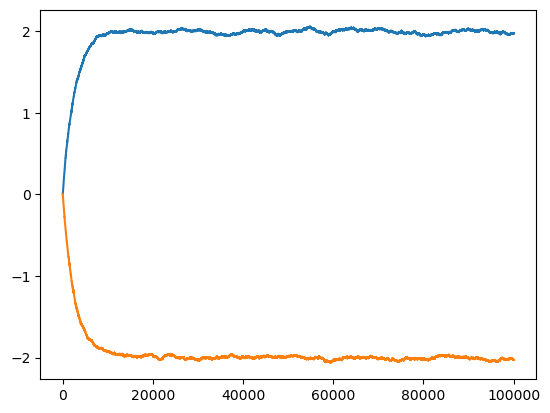

In [2]:
# Trying to get this stochastic gradient descent algo to function.
d = 2
mu_unknown = np.array([2, -2])
sigma_known = np.array([1,1])

N = 100000  # number of data points
# Generate the data for normal
X_data = np.random.normal(mu_unknown, sigma_known, (N, d))

# reasonable parameters
theta_0 = np.zeros(d)
beta = 1e6
lambda_ = 0.001
N_sgld = 100000
t_0 = 0
T = 1

theta_hat, theta_tracker = fct.thetahat_func(X_data = X_data, beta= beta, lambda_= lambda_, 
                          theta_0= theta_0, N_sgld= N_sgld, t_0= t_0, T = T)

print(theta_hat)
plt.plot(theta_tracker)

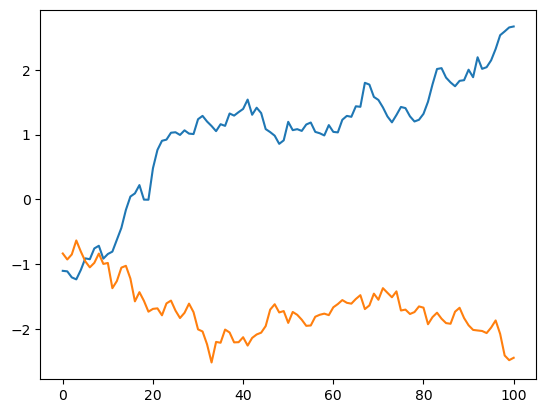

In [3]:
sample, path = fct.euler_maruyama_sample(theta_hat=theta_hat, gamma=0.01, T = 1, d = 2)
sample

plt.plot(path)

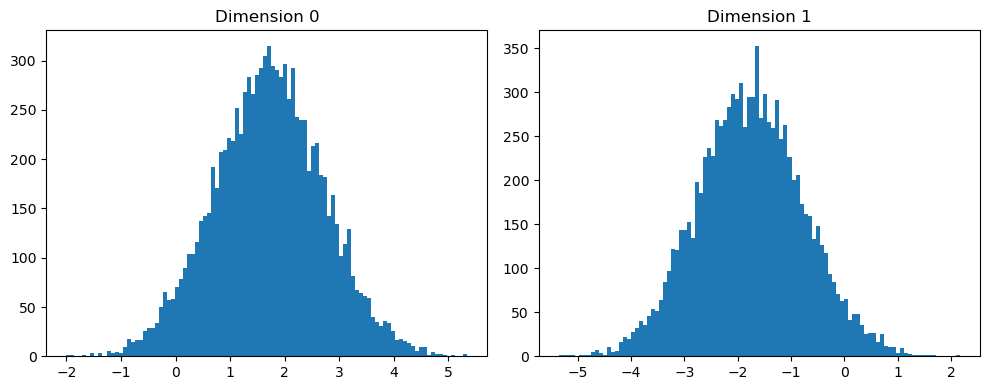

In [4]:
# Now I want to verify the distribution of the samples is in line with what I should expect.
# print(sample)

# N_samples = 100000
N_samples = 10_000
samples = []
for i in range(N_samples):
    sample, path = fct.euler_maruyama_sample(theta_hat=theta_hat, gamma=0.001, T = 1, d = 2)
    samples.append(sample)


samples_arr = np.array(samples) # shape (N_samples, d)

fig, axes = plt.subplots(1, d, figsize=(10, 4))

for i in range(d):
    axes[i].hist(samples_arr[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")

plt.tight_layout()
plt.show()

iter 0, loss = 3.2139
iter 500, loss = 2.1498
iter 1000, loss = 4.9848
iter 1500, loss = 15.6834
iter 2000, loss = 3.2527
iter 2500, loss = 5.0608
iter 3000, loss = 1.5637
iter 3500, loss = 4.2695
iter 4000, loss = 2.3512
iter 4500, loss = 4.2298
NN sample mean: [ 1.66746734 -1.67377747]
True mu:        [ 2 -2]


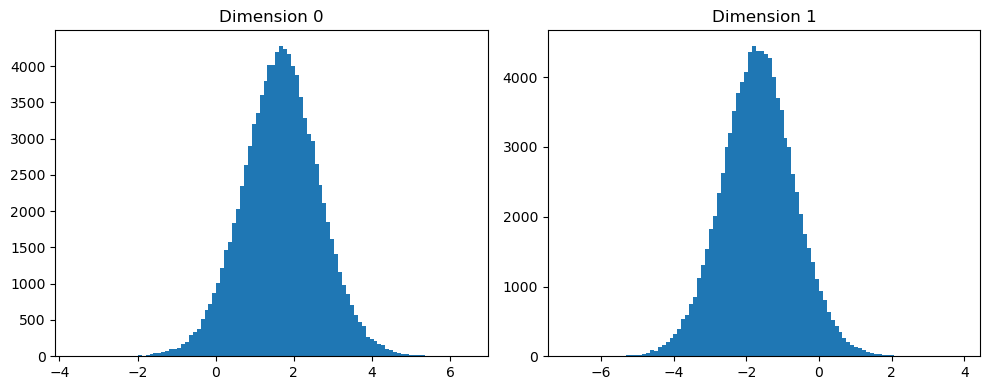

In [5]:
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

d = 2
net = fct.ScoreNet(d=d, D_1=32)

net = fct.train_score_net(net, X_data, t_0=0, T=1, d=d,
                       n_iters=5000, batch_size=256, lr=1e-3, device=device)

samples_nn_arr = fct.euler_maruyama_sample_nn_batch(net, gamma=0.001, T=1, d=d,
                                                  N_samples=100000, device=device)

print("NN sample mean:", samples_nn_arr.mean(axis=0))
print("True mu:       ", mu_unknown)


# Plot the distributions of the samples
fig, axes = plt.subplots(1, d, figsize=(10, 4))

for i in range(d):
    axes[i].hist(samples_nn_arr[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")

plt.tight_layout()
plt.show()

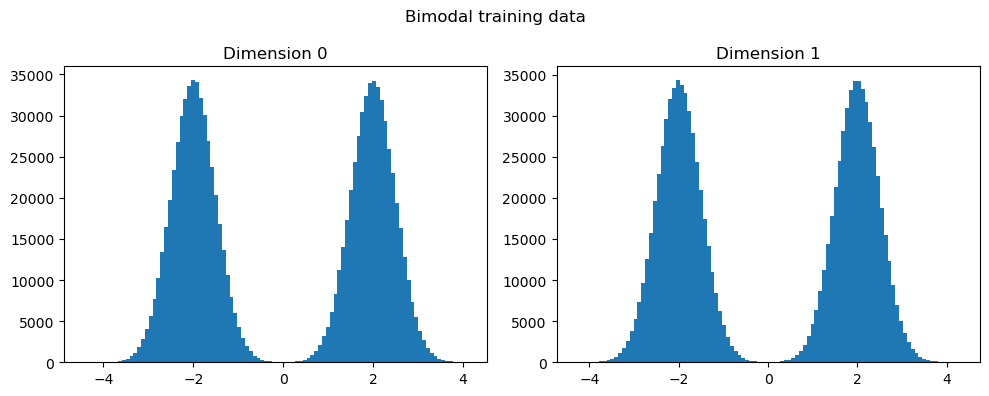

In [24]:
d = 2
mu1 = np.array([2.0, 2.0])
mu2 = np.array([-2.0, -2.0])
weight = 0.5
sigma = .5


X_data_bimodal = fct.sample_bimodal_data(N=1000000, d=d, mu1=mu1, mu2=mu2, sigma=sigma, weight=weight)

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")
plt.suptitle("Bimodal training data")
plt.tight_layout()
plt.show()

iter 0, loss = 3.6644
iter 500, loss = 3.8231
iter 1000, loss = 4.0154
iter 1500, loss = 3.4588
iter 2000, loss = 3.0775
iter 2500, loss = 3.1832
iter 3000, loss = 3.1411
iter 3500, loss = 2.7129
iter 4000, loss = 2.5386
iter 4500, loss = 3.7521
iter 5000, loss = 4.9542
iter 5500, loss = 3.0150
iter 6000, loss = 3.2370
iter 6500, loss = 4.1305
iter 7000, loss = 3.2383
iter 7500, loss = 5.3645
iter 8000, loss = 3.7112
iter 8500, loss = 2.2864
iter 9000, loss = 3.4267
iter 9500, loss = 3.4134
NN sample mean:     [-0.1178598   0.11640637]
True mixture mean:  [0. 0.]


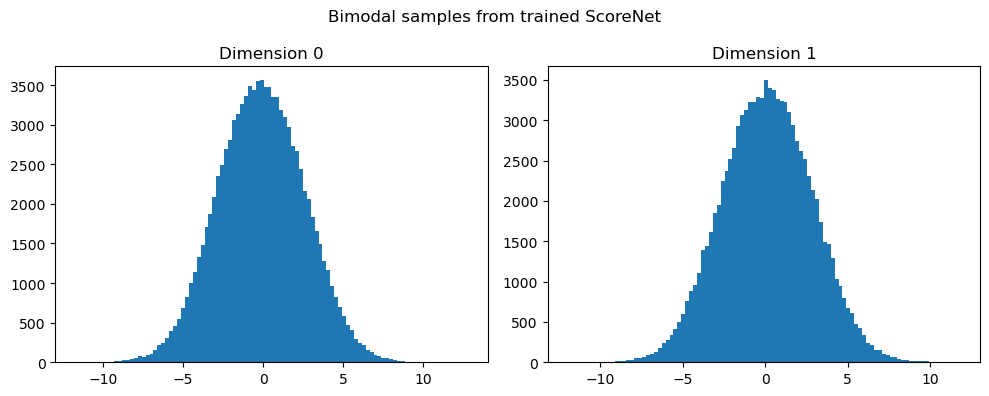

In [7]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

d = 2
D_1_bimodal = 128

net_bimodal = fct.ScoreNet(d=d, D_1=D_1_bimodal)

net_bimodal = fct.train_score_net(
    net_bimodal, X_data_bimodal,
    t_0=1e-3, T=1, d=d,
    n_iters=10_000, batch_size=512, lr=1e-3,
    device=device
)

samples_bimodal = fct.euler_maruyama_sample_nn_batch(
    net_bimodal, gamma=0.001, T=1, d=d,
    N_samples=100_000, device=device
)

true_mixture_mean = weight * mu1 + (1 - weight) * mu2

print("NN sample mean:    ", samples_bimodal.mean(axis=0))
print("True mixture mean: ", true_mixture_mean)

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(samples_bimodal[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")
plt.suptitle("Bimodal samples from trained ScoreNet")
plt.tight_layout()
plt.show()

iter 0, loss = 3.2496
iter 500, loss = 2.9314
iter 1000, loss = 3.8273
iter 1500, loss = 3.6478
iter 2000, loss = 4.4322
iter 2500, loss = 4.1825
iter 3000, loss = 3.0530
iter 3500, loss = 4.1630
iter 4000, loss = 3.0241
iter 4500, loss = 3.9168
iter 5000, loss = 3.0000
iter 5500, loss = 3.7646
iter 6000, loss = 4.1389
iter 6500, loss = 3.2642
iter 7000, loss = 4.5705
iter 7500, loss = 4.0158
iter 8000, loss = 4.2908
iter 8500, loss = 3.3774
iter 9000, loss = 2.7863
iter 9500, loss = 3.4197
3-layer NN sample mean:     [-0.06374154 -0.14919567]
True mixture mean:          [0. 0.]


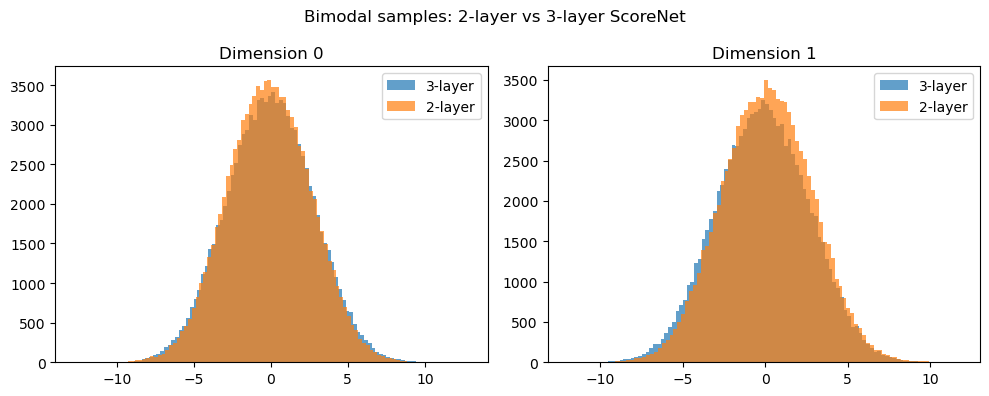

In [8]:
D_1_bimodal_3 = 128
D_2_bimodal_3 = 128

net_bimodal_3 = fct.ScoreNet3(d=d, D_1=D_1_bimodal_3, D_2=D_2_bimodal_3)

net_bimodal_3 = fct.train_score_net(
    net_bimodal_3, X_data_bimodal,
    t_0=1e-3, T=1, d=d,
    n_iters=10_000, batch_size=512, lr=1e-3,
    device=device
)

samples_bimodal_3 = fct.euler_maruyama_sample_nn_batch(
    net_bimodal_3, gamma=0.001, T=1, d=d,
    N_samples=100_000, device=device
)

print("3-layer NN sample mean:    ", samples_bimodal_3.mean(axis=0))
print("True mixture mean:         ", true_mixture_mean)

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(samples_bimodal_3[:, i], bins=100, alpha=0.7, label="3-layer")
    axes[i].hist(samples_bimodal[:, i],   bins=100, alpha=0.7, label="2-layer")
    axes[i].set_title(f"Dimension {i}")
    axes[i].legend()
plt.suptitle("Bimodal samples: 2-layer vs 3-layer ScoreNet")
plt.tight_layout()
plt.show()

In [9]:
print("mu1:", mu1, "mu2:", mu2)
print("weight:", weight)
print("X_data_bimodal mean per dim:", X_data_bimodal.mean(axis=0))
print("X_data_bimodal std per dim: ", X_data_bimodal.std(axis=0))

mu1: [2. 2.] mu2: [-2. -2.]
weight: 0.5
X_data_bimodal mean per dim: [0.00664818 0.00159826]
X_data_bimodal std per dim:  [3.6091537  3.60441301]


In [10]:

N_w2 = 5000

# X_data_bimodal is already a sample from pi_D - use a subset as ground truth
samples_true = X_data_bimodal[:N_w2]
samples_2layer = samples_bimodal[:N_w2]
samples_3layer = samples_bimodal_3[:N_w2]

# Uniform weights - each sample carries mass 1/N
a = np.ones(N_w2) / N_w2
b = np.ones(N_w2) / N_w2

# Cost matrices M_ij = |y_i - x_j|^2
M_2layer = ot.dist(samples_2layer, samples_true, metric='sqeuclidean')
M_3layer = ot.dist(samples_3layer, samples_true, metric='sqeuclidean')

# Solve exact OT linear programme, take square root for W_2
W2_2layer = np.sqrt(ot.emd2(a, b, M_2layer, numItermax=1000000))
W2_3layer = np.sqrt(ot.emd2(a, b, M_3layer, numItermax=1000000))

print(f"W2 (2-layer ScoreNet): {W2_2layer:.4f}")
print(f"W2 (3-layer ScoreNet): {W2_3layer:.4f}")

W2 (2-layer ScoreNet): 1.3979
W2 (3-layer ScoreNet): 1.2496


Checkpoint 1000...
  W2 2-layer: 1.2348 ± 0.0000 | W2 3-layer: 1.3213 ± 0.0000
Checkpoint 2000...
  W2 2-layer: 1.2426 ± 0.0000 | W2 3-layer: 1.3303 ± 0.0000
Checkpoint 5000...
  W2 2-layer: 1.3909 ± 0.0000 | W2 3-layer: 1.2929 ± 0.0000
Checkpoint 10000...
  W2 2-layer: 1.3770 ± 0.0000 | W2 3-layer: 1.1263 ± 0.0000
Checkpoint 20000...
  W2 2-layer: 1.1429 ± 0.0000 | W2 3-layer: 1.2850 ± 0.0000


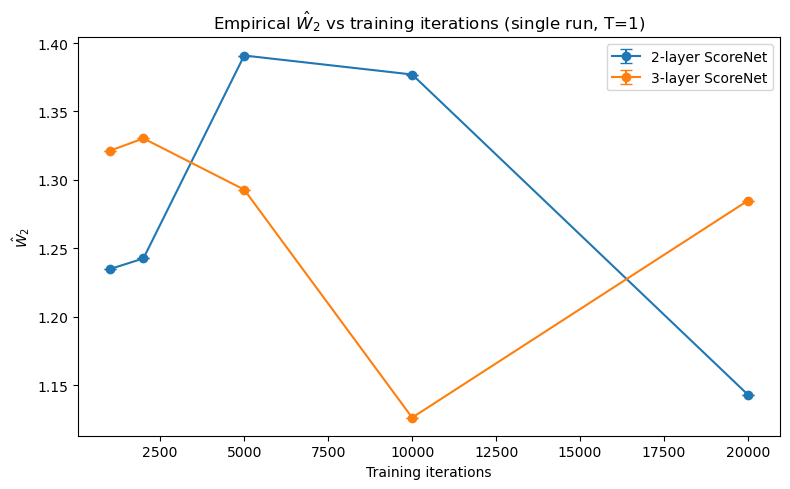

In [ ]:
checkpoints = [100, 250, 500, 1000, 2000, 5000, 10000, 20000]

results_single = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=1, T=1
)

fct.plot_W2_curve(results_single, title_suffix="(single run, T=1)")

i find that the curves for both the 3 layer neural net and the 2 layer neural net in non monotone decreasing. This means that there could be a computational ceiling on how well this implementation fits the data. 

Checkpoint 1000...
  W2 2-layer: 1.4542 ± 0.0336 | W2 3-layer: 1.2978 ± 0.0265
Checkpoint 2000...
  W2 2-layer: 1.3609 ± 0.0600 | W2 3-layer: 1.3141 ± 0.0557
Checkpoint 5000...
  W2 2-layer: 1.3480 ± 0.0290 | W2 3-layer: 1.2236 ± 0.0291
Checkpoint 10000...
  W2 2-layer: 1.3067 ± 0.0110 | W2 3-layer: 1.2213 ± 0.0477
Checkpoint 20000...
  W2 2-layer: 1.3381 ± 0.0452 | W2 3-layer: 1.2268 ± 0.0239


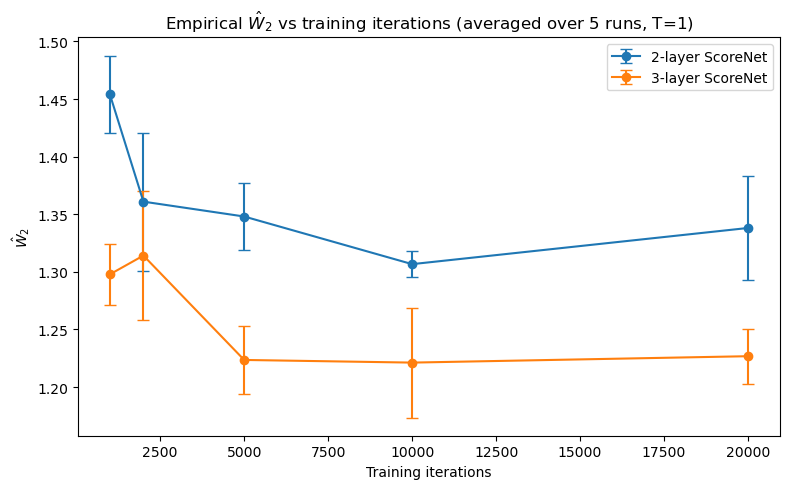

In [12]:
results_T1 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=1
)

fct.plot_W2_curve(results_T1, title_suffix="(averaged over 5 runs, T=1)")

We cannot improve the distance between the distribution here by increasing the number training iterations. THe $\epsilon_{SN}$ is the error of the network estimated score. 


$$\varepsilon_{SN} = \int_\epsilon^T \frac{\kappa(t)}{T - \epsilon} \int_{\mathbb{R}^d} \bigl|\nabla_x \log p_t(x) - s(t, \hat{\theta}, x)\bigr|^2 p_t(x)\, dx\, dt.$$

iter 0, loss = 4.1554
T = 1: W2 = 1.2077 ± 0.0297
iter 0, loss = 3.8405
T = 1.5: W2 = 0.6053 ± 0.0166
iter 0, loss = 2.1523
T = 1.75: W2 = 0.5678 ± 0.0030
iter 0, loss = 2.2350
T = 2: W2 = 0.5702 ± 0.0450
iter 0, loss = 1.8616
T = 2.5: W2 = 0.5502 ± 0.0317
iter 0, loss = 1.5995
T = 3: W2 = 0.5726 ± 0.0608
iter 0, loss = 1.5694
T = 4: W2 = 0.9153 ± 0.0419
iter 0, loss = 1.4538
T = 5: W2 = 0.9909 ± 0.5223
iter 0, loss = 1.3073
T = 10: W2 = 0.7354 ± 0.0208


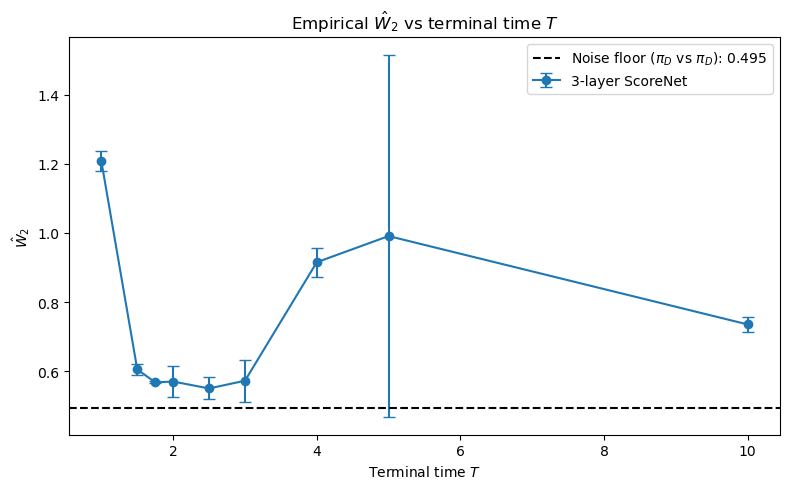

In [13]:
N_w2 = 2000
samples_true = X_data_bimodal[:N_w2]

T_values = [1, 1.5, 1.75, 2, 2.5, 3, 4, 5, 10]
W2_means = []
W2_stds = []

for T_val in T_values:
    net_test = fct.ScoreNet3(d=d, D_1=128, D_2=128).to(device)
    net_test = fct.train_score_net(
        net_test, X_data_bimodal,
        t_0=1e-3, T=T_val, d=d,
        n_iters=20000, batch_size=512, lr=1e-3,
        device=device, print_every=20001
    )
    w2_mean, w2_std = fct.estimate_W2(
        net_test, samples_true, N_w2=N_w2,
        n_repeats=5, gamma=0.001, T=T_val,
        d=d, device=device
    )
    W2_means.append(w2_mean)
    W2_stds.append(w2_std)
    print(f"T = {T_val}: W2 = {w2_mean:.4f} ± {w2_std:.4f}")

W2_self = 0.4949

plt.figure(figsize=(8, 5))
plt.errorbar(T_values, W2_means, yerr=W2_stds,
             marker='o', capsize=4, label='3-layer ScoreNet')
plt.axhline(W2_self, color='k', linestyle='--',
            label=f'Noise floor ($\\pi_D$ vs $\\pi_D$): {W2_self:.3f}')
plt.xlabel('Terminal time $T$')
plt.ylabel(r'$\hat{W}_2$')
plt.title(r'Empirical $\hat{W}_2$ vs terminal time $T$')
plt.legend()
plt.tight_layout()
plt.show()

This reduction in loss can be explained by the $C_2$ term in the error bound. 

$e^{-2\hat{L}_{\mathrm{MO}}(T - \epsilon) - \epsilon}$

The larger T increases the negative exponent on the exponential multiplying the bound on $C_2$ constant. It seems as though there is a sweetspot for the choice of T.  

Checkpoint 1000...
  W2 2-layer: 1.1928 ± 0.0281 | W2 3-layer: 0.7060 ± 0.0313
Checkpoint 2000...
  W2 2-layer: 0.7507 ± 0.0259 | W2 3-layer: 0.8210 ± 0.0564
Checkpoint 5000...
  W2 2-layer: 0.7357 ± 0.0932 | W2 3-layer: 0.7374 ± 0.0469
Checkpoint 10000...
  W2 2-layer: 0.6015 ± 0.0313 | W2 3-layer: 0.6063 ± 0.0371
Checkpoint 20000...
  W2 2-layer: 0.6862 ± 0.0513 | W2 3-layer: 0.7570 ± 0.0437


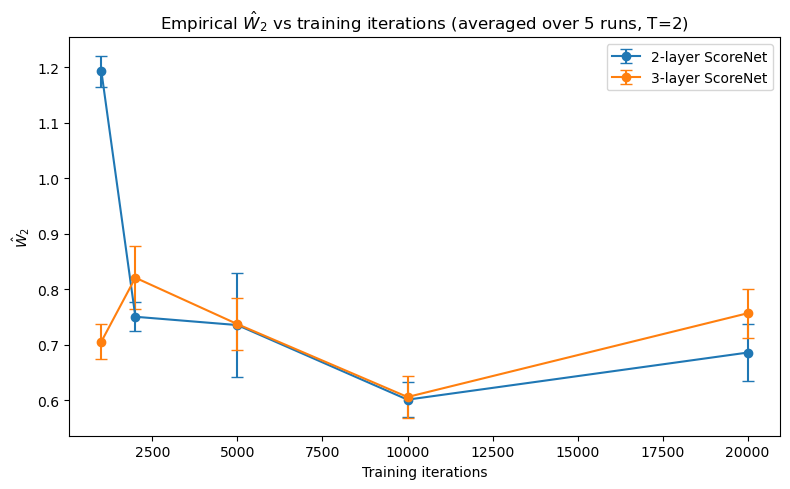

In [14]:
results_T2 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=2
)

fct.plot_W2_curve(results_T2, title_suffix="(averaged over 5 runs, T=2)")

Checkpoint 1000...
  W2 2-layer: 2.0543 ± 0.2349 | W2 3-layer: 1.2568 ± 0.0982
Checkpoint 2000...
  W2 2-layer: 0.8386 ± 0.0919 | W2 3-layer: 0.8779 ± 0.0289
Checkpoint 5000...
  W2 2-layer: 0.7806 ± 0.0876 | W2 3-layer: 0.8537 ± 0.0276
Checkpoint 10000...
  W2 2-layer: 0.6664 ± 0.0225 | W2 3-layer: 0.6243 ± 0.0455
Checkpoint 20000...
  W2 2-layer: 0.6906 ± 0.0667 | W2 3-layer: 0.5752 ± 0.0444


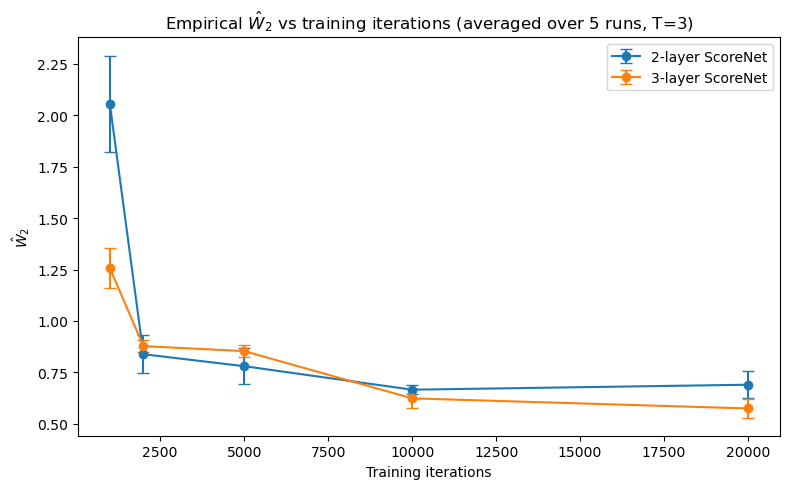

In [15]:
results_T3 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=3
)

fct.plot_W2_curve(results_T3, title_suffix="(averaged over 5 runs, T=3)")

In [16]:
# Checking the quality of the wasserstein distance solver error

N_w2 = 5000
samples_true   = X_data_bimodal[:N_w2]
samples_true_2 = X_data_bimodal[N_w2:2*N_w2]

a = np.ones(N_w2) / N_w2
b = np.ones(N_w2) / N_w2

M = ot.dist(samples_true, samples_true_2, metric='sqeuclidean')
W2_self = np.sqrt(ot.emd2(a, b, M, numItermax=1000000))
print(f"W2 between two independent samples of pi_D (N={N_w2}): {W2_self:.4f}")

W2 between two independent samples of pi_D (N=5000): 0.3708


N =   500: noise floor = 0.9645 ± 0.0750
N =  1000: noise floor = 0.6808 ± 0.0761
N =  2000: noise floor = 0.5017 ± 0.0247
N =  3000: noise floor = 0.4281 ± 0.0185
N =  5000: noise floor = 0.3371 ± 0.0193
N = 10000: noise floor = 0.2513 ± 0.0097


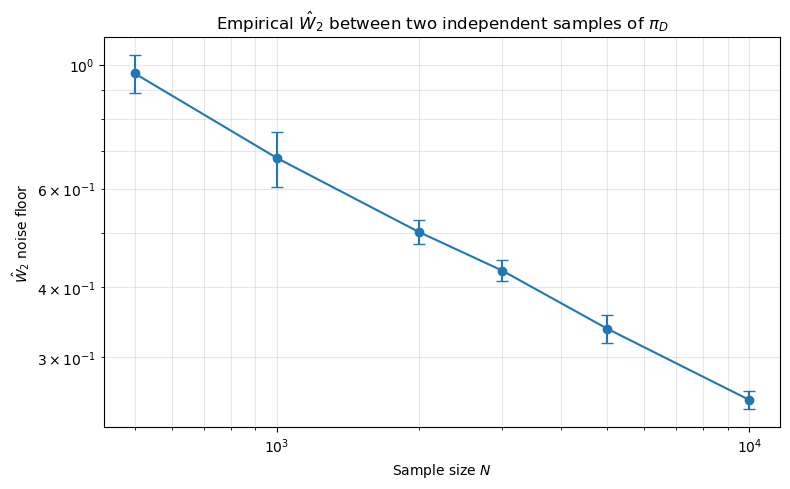

In [17]:
def W2_self_floor(X_data, N, n_repeats=5):
    """
    Estimate the W_2 noise floor at sample size N by computing W_2
    between two independent draws from X_data, averaged over n_repeats.
    """
    W2_vals = []
    a = np.ones(N) / N
    b = np.ones(N) / N
    for r in range(n_repeats):
        # Draw two disjoint subsets of X_data
        idx = np.random.permutation(len(X_data))
        s1 = X_data[idx[:N]]
        s2 = X_data[idx[N:2*N]]
        M = ot.dist(s1, s2, metric='sqeuclidean')
        W2_vals.append(np.sqrt(ot.emd2(a, b, M, numItermax=10_000_000)))
    return np.mean(W2_vals), np.std(W2_vals)


sample_sizes = [ 500, 1000, 2000, 3000,  5000, 10000]
floors = []
floor_stds = []

for N in sample_sizes:
    mean, std = W2_self_floor(X_data_bimodal, N, n_repeats=5)
    floors.append(mean)
    floor_stds.append(std)
    print(f"N = {N:5d}: noise floor = {mean:.4f} ± {std:.4f}")

plt.figure(figsize=(8, 5))
plt.errorbar(sample_sizes, floors, yerr=floor_stds, marker='o', capsize=4)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Sample size $N$')
plt.ylabel(r'$\hat{W}_2$ noise floor')
plt.title(r'Empirical $\hat{W}_2$ between two independent samples of $\pi_D$')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

Checkpoint 1000...
  W2 2-layer: 1.9840 ± 0.0834 | W2 3-layer: 1.4757 ± 0.0339
Checkpoint 2000...
  W2 2-layer: 0.8042 ± 0.0188 | W2 3-layer: 0.7106 ± 0.0292
Checkpoint 5000...
  W2 2-layer: 0.5727 ± 0.0100 | W2 3-layer: 0.7034 ± 0.0259
Checkpoint 10000...
  W2 2-layer: 0.4680 ± 0.0381 | W2 3-layer: 0.5026 ± 0.0322
Checkpoint 20000...
  W2 2-layer: 0.7586 ± 0.0394 | W2 3-layer: 0.4650 ± 0.0217


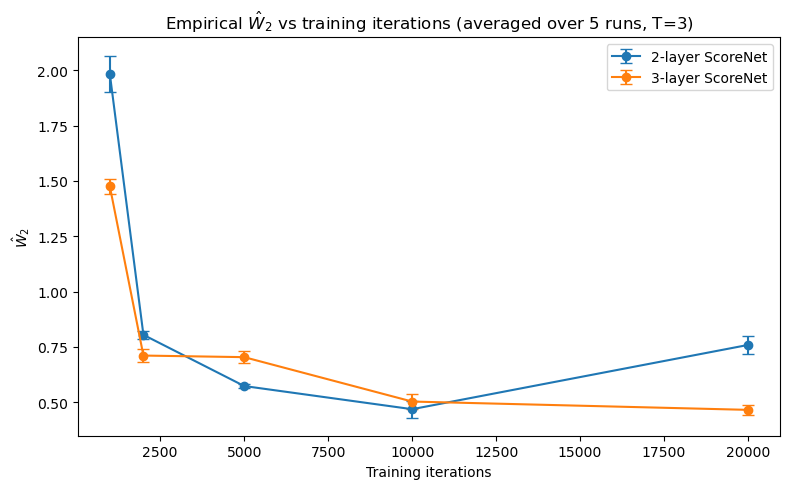

In [18]:
results_T3 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=3, N_w2= 10_000
)

fct.plot_W2_curve(results_T3, title_suffix="(averaged over 5 runs, T=3)")

Checkpoint 1000...
  W2 2-layer: 0.9384 ± 0.0527 | W2 3-layer: 0.8864 ± 0.0332
Checkpoint 2000...
  W2 2-layer: 0.5107 ± 0.0290 | W2 3-layer: 0.7465 ± 0.0207
Checkpoint 5000...
  W2 2-layer: 0.4782 ± 0.0162 | W2 3-layer: 0.5323 ± 0.0171
Checkpoint 10000...
  W2 2-layer: 0.6625 ± 0.0335 | W2 3-layer: 0.3510 ± 0.0212
Checkpoint 20000...
  W2 2-layer: 0.4327 ± 0.0097 | W2 3-layer: 0.6452 ± 0.0192


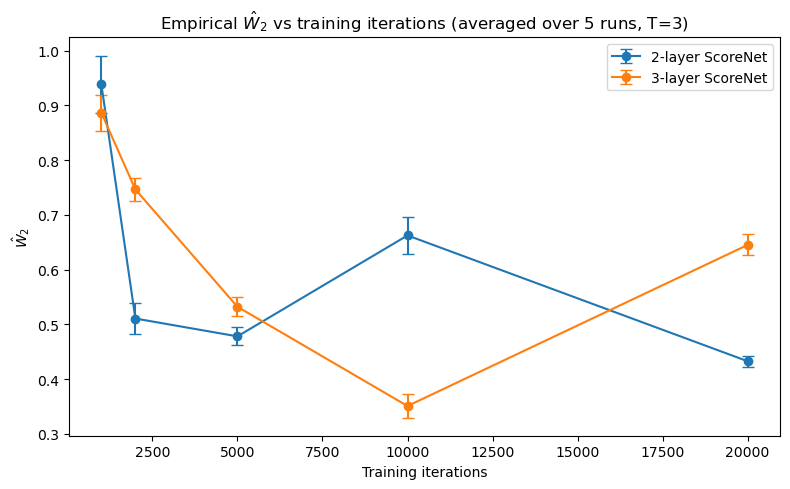

In [19]:
results_T4 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=2, N_w2= 10_000
)

fct.plot_W2_curve(results_T4, title_suffix="(averaged over 5 runs, T=3)")

In [20]:
checkpoints = [100, 250, 500, 1000, 2000, 5000, 10000, 20000]

results_single1000 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=1, T=1000
)

fct.plot_W2_curve(results_single1000, title_suffix="(single run, T=1000)")

Checkpoint 100...


Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Caused GPU Hang Error (00000003:kIOGPUCommandBufferCallbackErrorHang)
	<AGXG16GFamilyCommandBuffer: 0x31397b310>
    label = <none> 
    device = <AGXG16GDevice: 0x30fbd6e00>
        name = Apple M4 
    commandQueue = <AGXG16GFamilyCommandQueue: 0x30fbd5e00>
        label = <none> 
        device = <AGXG16GDevice: 0x30fbd6e00>
            name = Apple M4 
    retainedReferences = 1


KeyboardInterrupt: 